## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'

In [4]:
greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

In [5]:
greece_nuts3_gdf.head(5)

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [6]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [7]:
greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

In [8]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: epsg:4326


In [9]:
greece_nuts3_gdf.head(5)

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [10]:
print(f'Length of greece_nuts3_gdf: {len(greece_nuts3_gdf)}')

Length of greece_nuts3_gdf: 52


In [11]:
#choose the correct region

nuts2_gdf = greece_nuts3_gdf.loc[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}'].copy()
nuts2_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
34,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL61,Thessalia,Θεσσαλία,EL611,"Karditsa, Trikala","Καρδίτσα, Τρίκαλα",2.0,3,3,"POLYGON ((21.91769 39.85205, 21.95557 39.84969..."
35,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL61,Thessalia,Θεσσαλία,EL612,Larisa,Λάρισα,2.0,2,1,"POLYGON ((22.66458 39.97476, 22.70870 39.95235..."
36,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL61,Thessalia,Θεσσαλία,EL613,"Magnisia, Sporades","Μαγνησία, Σποράδες",2.0,2,1,"MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


In [12]:
print(f'nuts2_gdf CRS: {nuts2_gdf.crs}')

nuts2_gdf CRS: epsg:4326


<AxesSubplot:>

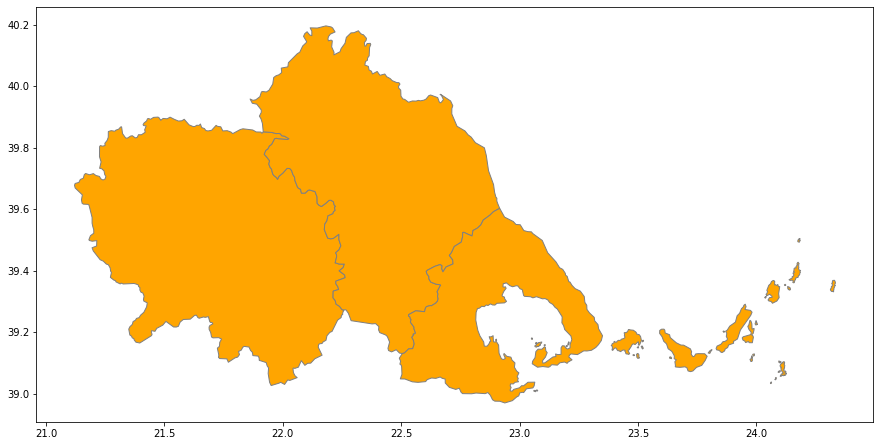

In [13]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [14]:
nuts2_gdf.NUTS3_NAME.unique()

array(['Καρδίτσα, Τρίκαλα', 'Λάρισα', 'Μαγνησία, Σποράδες'], dtype=object)

In [15]:
nuts2_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_LATN','NUTS3_LATN',
                        'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace = True)
nuts2_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts2_gdf, 'NUTS3_NAME')
process_greek(nuts2_gdf, 'NUTS2_NAME')

In [16]:
nuts2_gdf.head(5)

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,geometry
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα","POLYGON ((21.91769 39.85205, 21.95557 39.84969..."
1,EL61,θεσσαλια,EL612,λαρισα,"POLYGON ((22.66458 39.97476, 22.70870 39.95235..."
2,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες","MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


<AxesSubplot:>

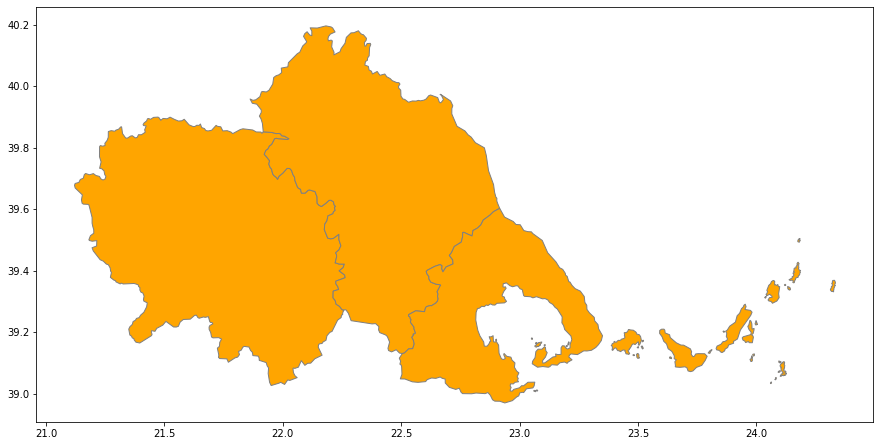

In [17]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [18]:
nuts3_units = nuts2_gdf['NUTS3_NAME'].unique().tolist()

if not os.path.exists(f'../../data/{NUTS2}/'):
    os.makedirs(f'../../data/{NUTS2}/')

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_NUTS3_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in nuts3_units:
        f.write("%s\n" % item)

print(f"Number of NUTS3 Units in {NUTS2} (from shapefile): {len(nuts3_units)}")

Number of NUTS3 Units in Thessaly (from shapefile): 3


In [19]:
nuts2_gdf.reset_index(inplace=True, drop = True)

In [27]:
#check QGIS for wrong lau1 units

In [20]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='NUTS3_NAME', dimension=4)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [21]:
df_grid.head()

,geometry,centers,NAME,x,y
0,"POLYGON ((21.21333 39.63719, 21.21333 39.67313...",POINT (21.19020725963661 39.655160206007515),"καρδιτσα, τρικαλα",21.19021,39.65516
1,"POLYGON ((21.21333 39.67313, 21.21333 39.70906...",POINT (21.19020725963661 39.691093589207945),"καρδιτσα, τρικαλα",21.19021,39.69109
2,"POLYGON ((21.25959 39.52939, 21.25959 39.56533...",POINT (21.236462099394352 39.54736005640623),"καρδιτσα, τρικαλα",21.23646,39.54736
3,"POLYGON ((21.25959 39.56533, 21.25959 39.60126...",POINT (21.236462099394352 39.583293439606656),"καρδιτσα, τρικαλα",21.23646,39.58329
4,"POLYGON ((21.25959 39.60126, 21.25959 39.63719...",POINT (21.236462099394352 39.61922682280708),"καρδιτσα, τρικαλα",21.23646,39.61923


In [22]:
df_grid.rename(columns={"NAME": "NUTS3_NAME"}, inplace = True)

In [105]:
grid_nuts3 = df_grid['nuts3'].unique().tolist()
print(f"Number of NUTS3 Units in Grid: {len(grid_nuts3)}")

Number of NUTS3 Units in Grid: 4


<AxesSubplot:>

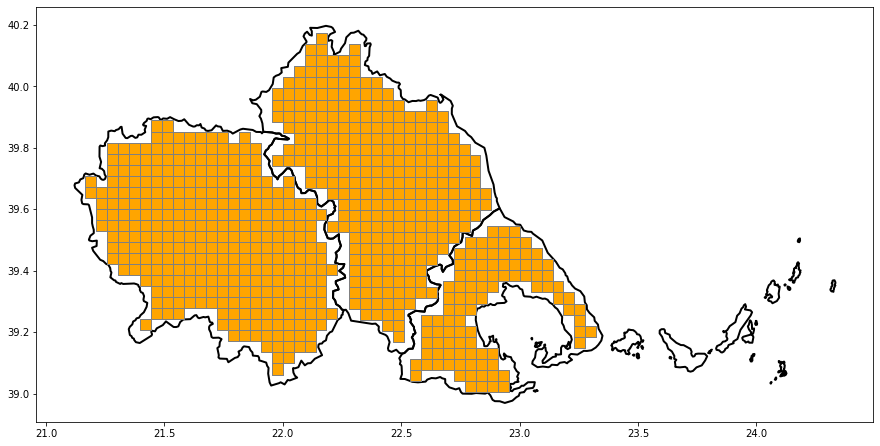

In [23]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [24]:
grid_nuts3 = df_grid['NUTS3_NAME'].unique().tolist()
print(f"Number of NUTS3 Units in Grid: {len(grid_nuts3)}")

Number of NUTS3 Units in Grid: 3


In [25]:
if (len(nuts3_units) != len(grid_nuts3)):
    delta = [item for item in nuts3_units if item not in grid_nuts3]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['NUTS3_NAME'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['NUTS3_NAME'] = lost_lau1['NUTS3_NAME']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [26]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [27]:
nuts2_grid

,geometry,NUTS3_NAME,x,y
0,"POLYGON ((21.21333 39.63719, 21.21333 39.67313...","καρδιτσα, τρικαλα",21.19021,39.65516
1,"POLYGON ((21.21333 39.67313, 21.21333 39.70906...","καρδιτσα, τρικαλα",21.19021,39.69109
2,"POLYGON ((21.25959 39.52939, 21.25959 39.56533...","καρδιτσα, τρικαλα",21.23646,39.54736
3,"POLYGON ((21.25959 39.56533, 21.25959 39.60126...","καρδιτσα, τρικαλα",21.23646,39.58329
4,"POLYGON ((21.25959 39.60126, 21.25959 39.63719...","καρδιτσα, τρικαλα",21.23646,39.61923
...,...,...,...,...
689,"POLYGON ((23.27775 39.14941, 23.27775 39.18535...","μαγνησια, σποραδες",23.25464,39.16738
690,"POLYGON ((23.27775 39.18535, 23.27775 39.22128...","μαγνησια, σποραδες",23.25464,39.20331
691,"POLYGON ((23.27775 39.22128, 23.27775 39.25722...","μαγνησια, σποραδες",23.25464,39.23925
692,"POLYGON ((23.27775 39.25722, 23.27775 39.29315...","μαγνησια, σποραδες",23.25464,39.27518


In [28]:
if (len(nuts3_units) != len(grid_nuts3)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [29]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [30]:
nuts2_grid

,shape,NUTS3_NAME,x,y
0,"POLYGON ((21.21333 39.63719, 21.21333 39.67313...","καρδιτσα, τρικαλα",21.19021,39.65516
1,"POLYGON ((21.21333 39.67313, 21.21333 39.70906...","καρδιτσα, τρικαλα",21.19021,39.69109
2,"POLYGON ((21.25959 39.52939, 21.25959 39.56533...","καρδιτσα, τρικαλα",21.23646,39.54736
3,"POLYGON ((21.25959 39.56533, 21.25959 39.60126...","καρδιτσα, τρικαλα",21.23646,39.58329
4,"POLYGON ((21.25959 39.60126, 21.25959 39.63719...","καρδιτσα, τρικαλα",21.23646,39.61923
...,...,...,...,...
689,"POLYGON ((23.27775 39.14941, 23.27775 39.18535...","μαγνησια, σποραδες",23.25464,39.16738
690,"POLYGON ((23.27775 39.18535, 23.27775 39.22128...","μαγνησια, σποραδες",23.25464,39.20331
691,"POLYGON ((23.27775 39.22128, 23.27775 39.25722...","μαγνησια, σποραδες",23.25464,39.23925
692,"POLYGON ((23.27775 39.25722, 23.27775 39.29315...","μαγνησια, σποραδες",23.25464,39.27518


In [31]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [32]:
nuts2_grid_points

,shape,NUTS3_NAME,x,y,geometry
0,"POLYGON ((21.21333 39.63719, 21.21333 39.67313...","καρδιτσα, τρικαλα",21.19021,39.65516,POINT (21.19021 39.65516)
1,"POLYGON ((21.21333 39.67313, 21.21333 39.70906...","καρδιτσα, τρικαλα",21.19021,39.69109,POINT (21.19021 39.69109)
2,"POLYGON ((21.25959 39.52939, 21.25959 39.56533...","καρδιτσα, τρικαλα",21.23646,39.54736,POINT (21.23646 39.54736)
3,"POLYGON ((21.25959 39.56533, 21.25959 39.60126...","καρδιτσα, τρικαλα",21.23646,39.58329,POINT (21.23646 39.58329)
4,"POLYGON ((21.25959 39.60126, 21.25959 39.63719...","καρδιτσα, τρικαλα",21.23646,39.61923,POINT (21.23646 39.61923)
...,...,...,...,...,...
689,"POLYGON ((23.27775 39.14941, 23.27775 39.18535...","μαγνησια, σποραδες",23.25464,39.16738,POINT (23.25464 39.16738)
690,"POLYGON ((23.27775 39.18535, 23.27775 39.22128...","μαγνησια, σποραδες",23.25464,39.20331,POINT (23.25464 39.20331)
691,"POLYGON ((23.27775 39.22128, 23.27775 39.25722...","μαγνησια, σποραδες",23.25464,39.23925,POINT (23.25464 39.23925)
692,"POLYGON ((23.27775 39.25722, 23.27775 39.29315...","μαγνησια, σποραδες",23.25464,39.27518,POINT (23.25464 39.27518)


<AxesSubplot:>

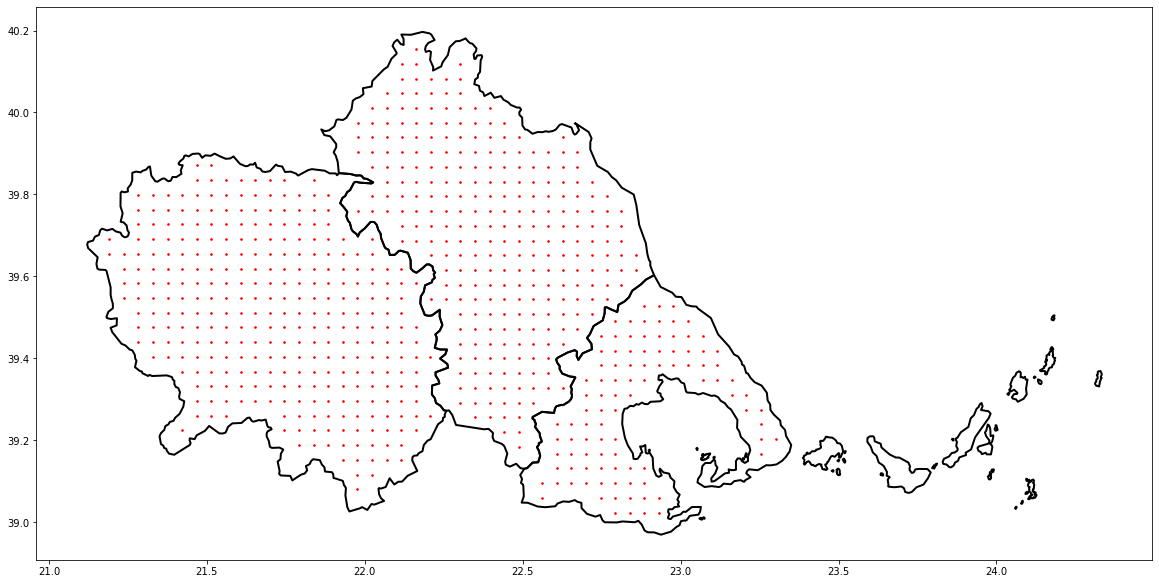

In [33]:
ax = nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [34]:
final_grid = pd.merge(nuts2_grid[['NUTS3_NAME', 'x', 'y']], nuts2_gdf[['NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], how='left', on=['NUTS3_NAME']) 
final_grid.sort_values(by=['NUTS3_NAME'], inplace = True)
final_grid = final_grid[['NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y']]

final_grid.reset_index(drop = True, inplace= True)

In [35]:
final_grid

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.88403,39.36769
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.88403,39.33176
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.88403,39.29583
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.88403,39.25989
...,...,...,...,...,...,...
689,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.31112
690,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.27518
691,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.23925
692,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.16738


In [36]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid_NUTS3.csv', encoding=enc, index = False)